# CIFAR-10 CNN

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

In [ ]:
os.makedirs("./results/confusion_matrix", exist_ok=True)

CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

full_train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)

dataset = Subset(full_train_dataset, range(10000))

split = int(len(dataset) * 0.8)
train_dataset = Subset(dataset, range(0, split))
val_dataset = Subset(dataset, range(split, len(dataset)))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Device: {device}")

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

EPOCHS = 15
train_losses, val_losses = [], []
train_accs, val_accs = [], []

Device: cuda


In [ ]:
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    train_losses.append(total_loss / total)
    train_accs.append(correct / total * 100)

    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)

            total_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)

    val_losses.append(total_loss / total)
    val_accs.append(correct / total * 100)

    print(f"Epoch [{epoch:2d}/{EPOCHS}]  Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.2f}%  |  Val Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.2f}%")

Epoch [ 1/15]  Train Loss: 2.1371  Acc: 20.20%  |  Val Loss: 2.0169  Acc: 26.25%
Epoch [ 2/15]  Train Loss: 1.8777  Acc: 29.98%  |  Val Loss: 1.8444  Acc: 33.25%
Epoch [ 3/15]  Train Loss: 1.6835  Acc: 37.61%  |  Val Loss: 1.6986  Acc: 39.35%
Epoch [ 4/15]  Train Loss: 1.5702  Acc: 42.44%  |  Val Loss: 1.5747  Acc: 41.90%
Epoch [ 5/15]  Train Loss: 1.5122  Acc: 44.70%  |  Val Loss: 1.5496  Acc: 43.30%
Epoch [ 6/15]  Train Loss: 1.4521  Acc: 46.58%  |  Val Loss: 1.4498  Acc: 47.70%
Epoch [ 7/15]  Train Loss: 1.3931  Acc: 48.75%  |  Val Loss: 1.4354  Acc: 47.60%
Epoch [ 8/15]  Train Loss: 1.3576  Acc: 50.66%  |  Val Loss: 1.4105  Acc: 48.55%
Epoch [ 9/15]  Train Loss: 1.2987  Acc: 52.85%  |  Val Loss: 1.3552  Acc: 51.50%
Epoch [10/15]  Train Loss: 1.2640  Acc: 54.09%  |  Val Loss: 1.3836  Acc: 49.90%
Epoch [11/15]  Train Loss: 1.2120  Acc: 55.81%  |  Val Loss: 1.2920  Acc: 53.75%
Epoch [12/15]  Train Loss: 1.1653  Acc: 57.40%  |  Val Loss: 1.2702  Acc: 55.10%
Epoch [13/15]  Train Loss: 1

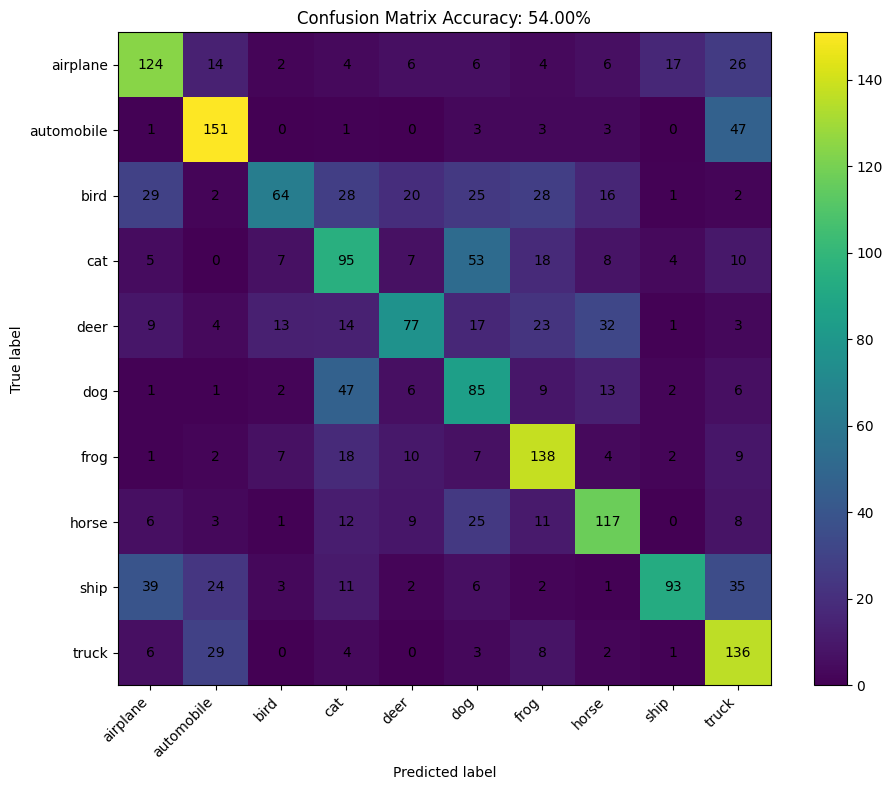

In [ ]:
model.eval()
confusion = np.zeros((10, 10), dtype=int)

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()

        for t, p in zip(labels.numpy(), preds):
            confusion[t][p] += 1

accuracy = np.trace(confusion) / np.sum(confusion) * 100

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confusion)

ax.set_xticks(np.arange(len(CLASSES)))
ax.set_yticks(np.arange(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Confusion Matrix Accuracy: {accuracy:.2f}%")

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax.text(j, i, confusion[i, j], ha="center", va="center")

fig.colorbar(im)
fig.tight_layout()
plt.savefig("./results/confusion_matrix/confusion_matrix.png", dpi=300)
plt.show()

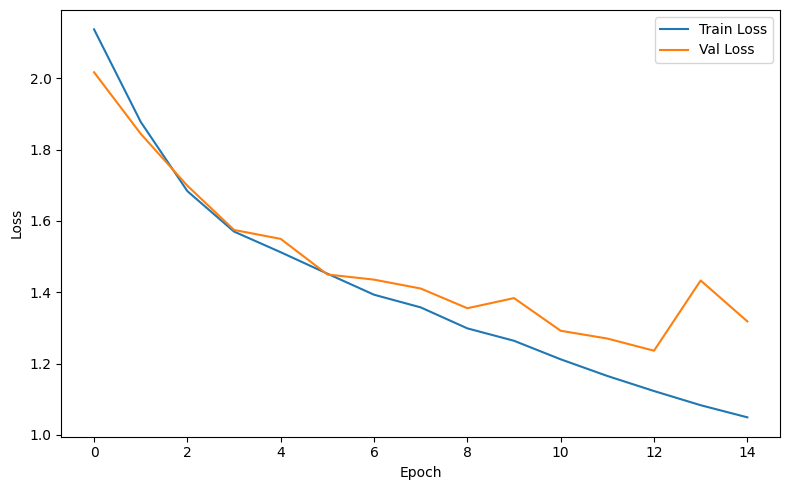

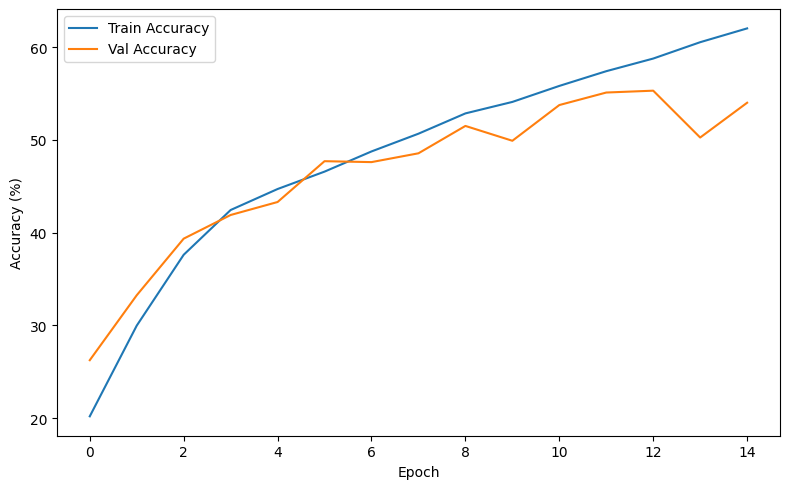

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("./results/loss_summary.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.savefig("./results/accuracy_summary.png", dpi=300)
plt.show()

In [ ]:
print(f"Best Validation Accuracy: {max(val_accs):.2f}%")
print(f"Final Validation Accuracy: {val_accs[-1]:.2f}%")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

Best Validation Accuracy: 55.30%
Final Validation Accuracy: 54.00%
Final Validation Loss: 1.3183
